In [6]:
from ultralytics import YOLO 
 
# 1. Cargar un modelo pre-entrenado (YOLOv8 nano es rápido y ligero) 
model = YOLO('yolo11s.pt')  
 
# 2. Entrenar el modelo 
results = model.train( 
    data='dataset-piedra-papel-tijeras/data.yaml',  
    epochs=50,                # Número de vueltas al dataset 
    imgsz=640,                # Tamaño de la imagen 
    plots=True,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.8 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16083MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset-piedra-papel-tijeras/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64

In [ ]:
from ultralytics import YOLO 
import cv2 
 
# Cargar el modelo entrenado 
model = YOLO('runs/detect/train/weights/best.pt') 
 
# Predecir en una imagen nueva 
results = model.predict('ruta/a/tu/foto_test.jpg', save=True) 
 
# Ver los resultados 
for r in results: 
    print(r.boxes) # Muestra las cajas detectadas 

Resultados en: runs/detect/train

Visualizaciones

Curvas de entrenamiento:


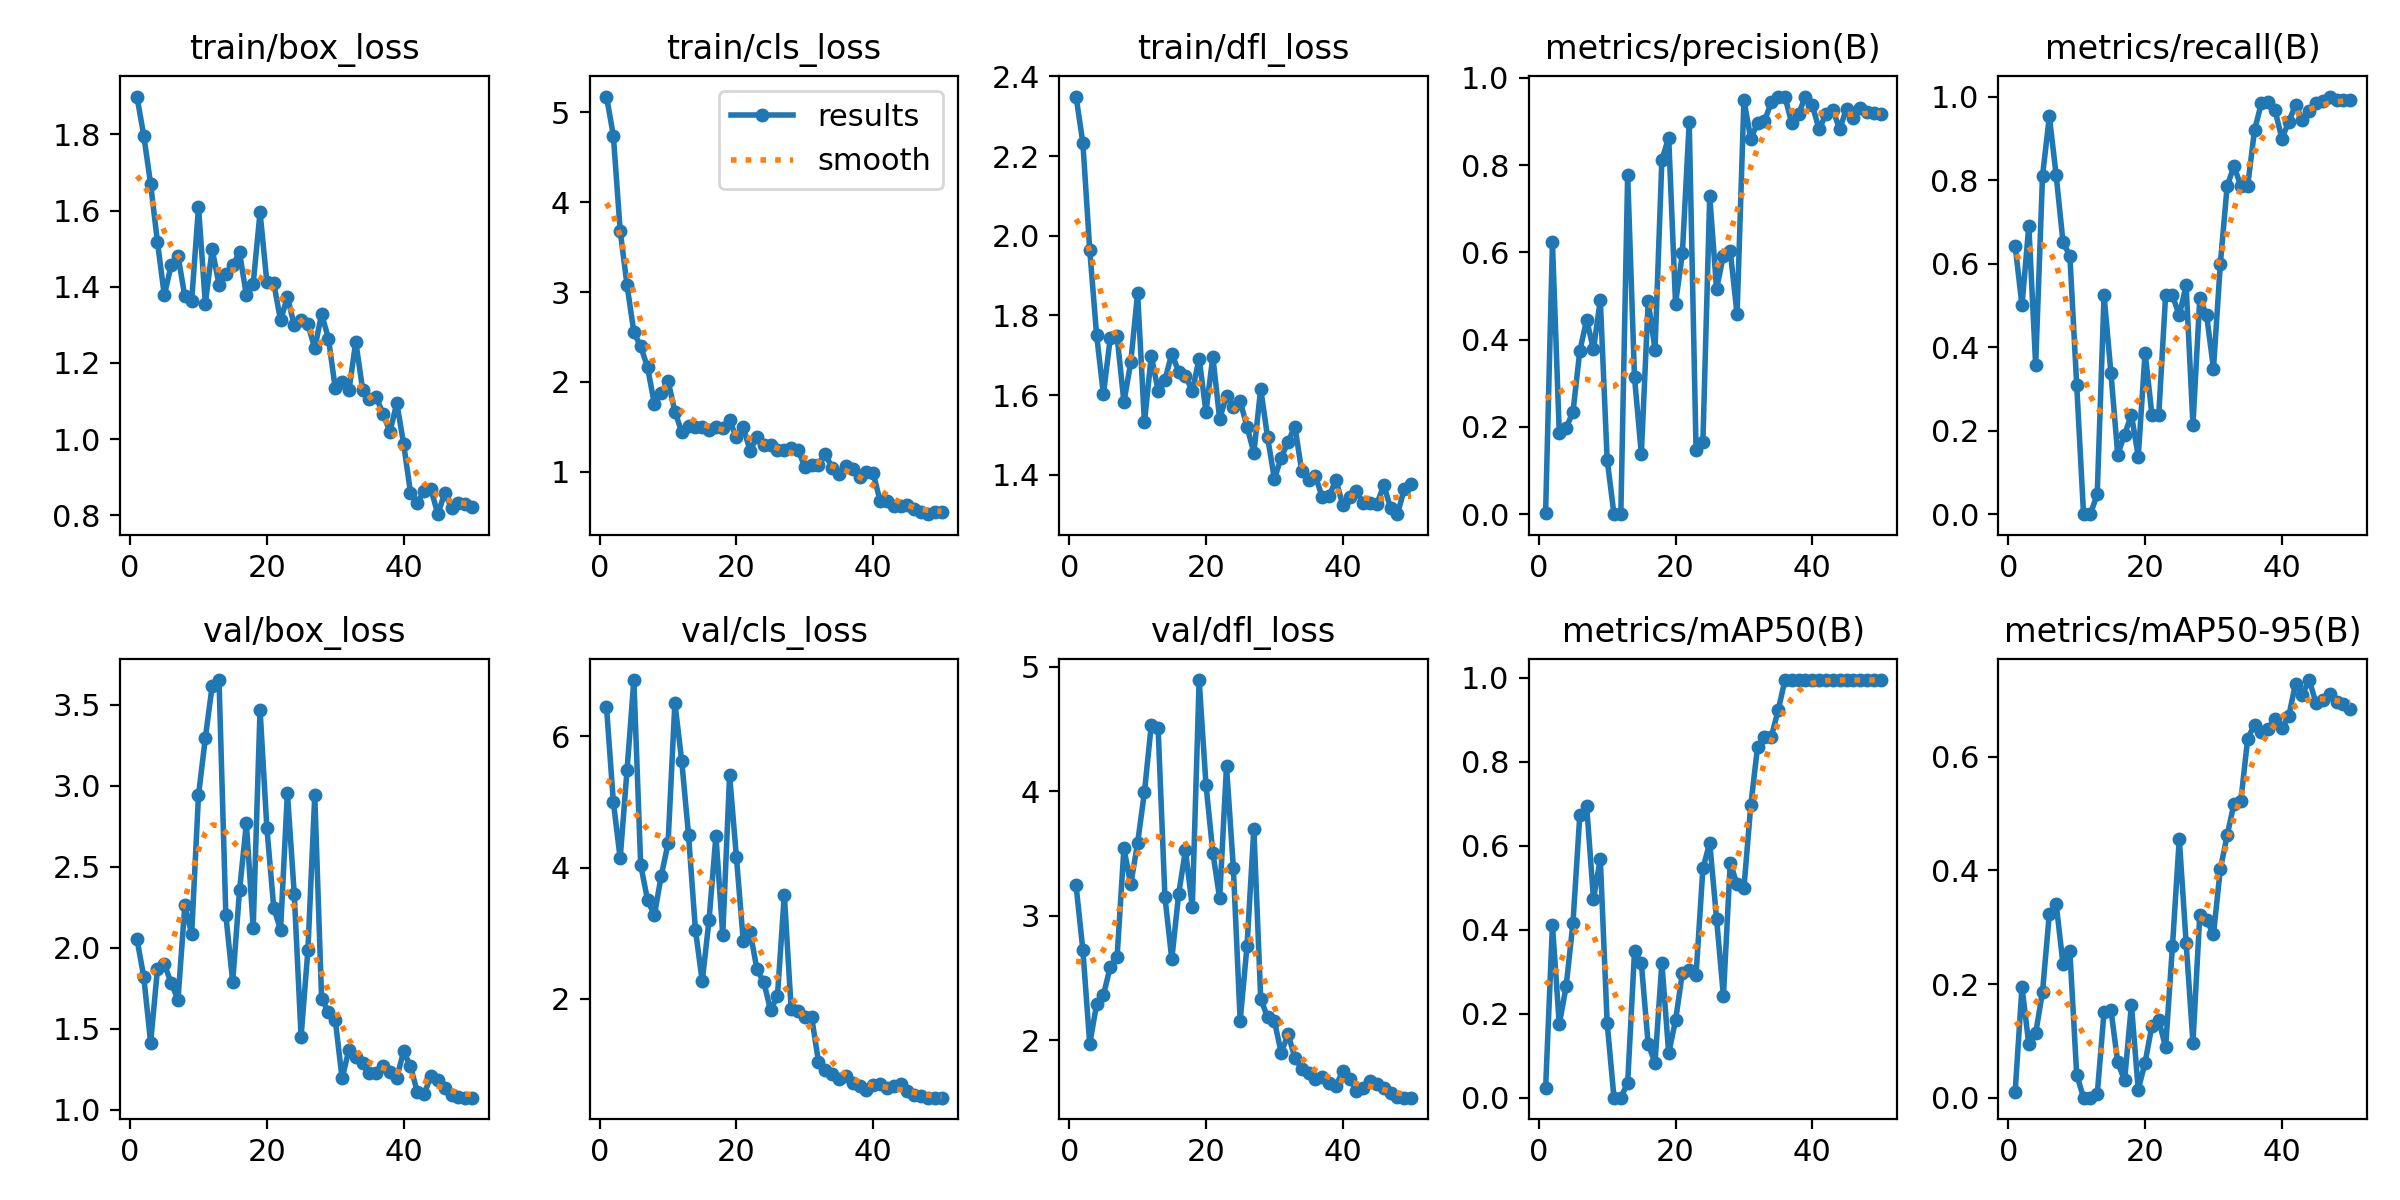


Predicciones de validación:


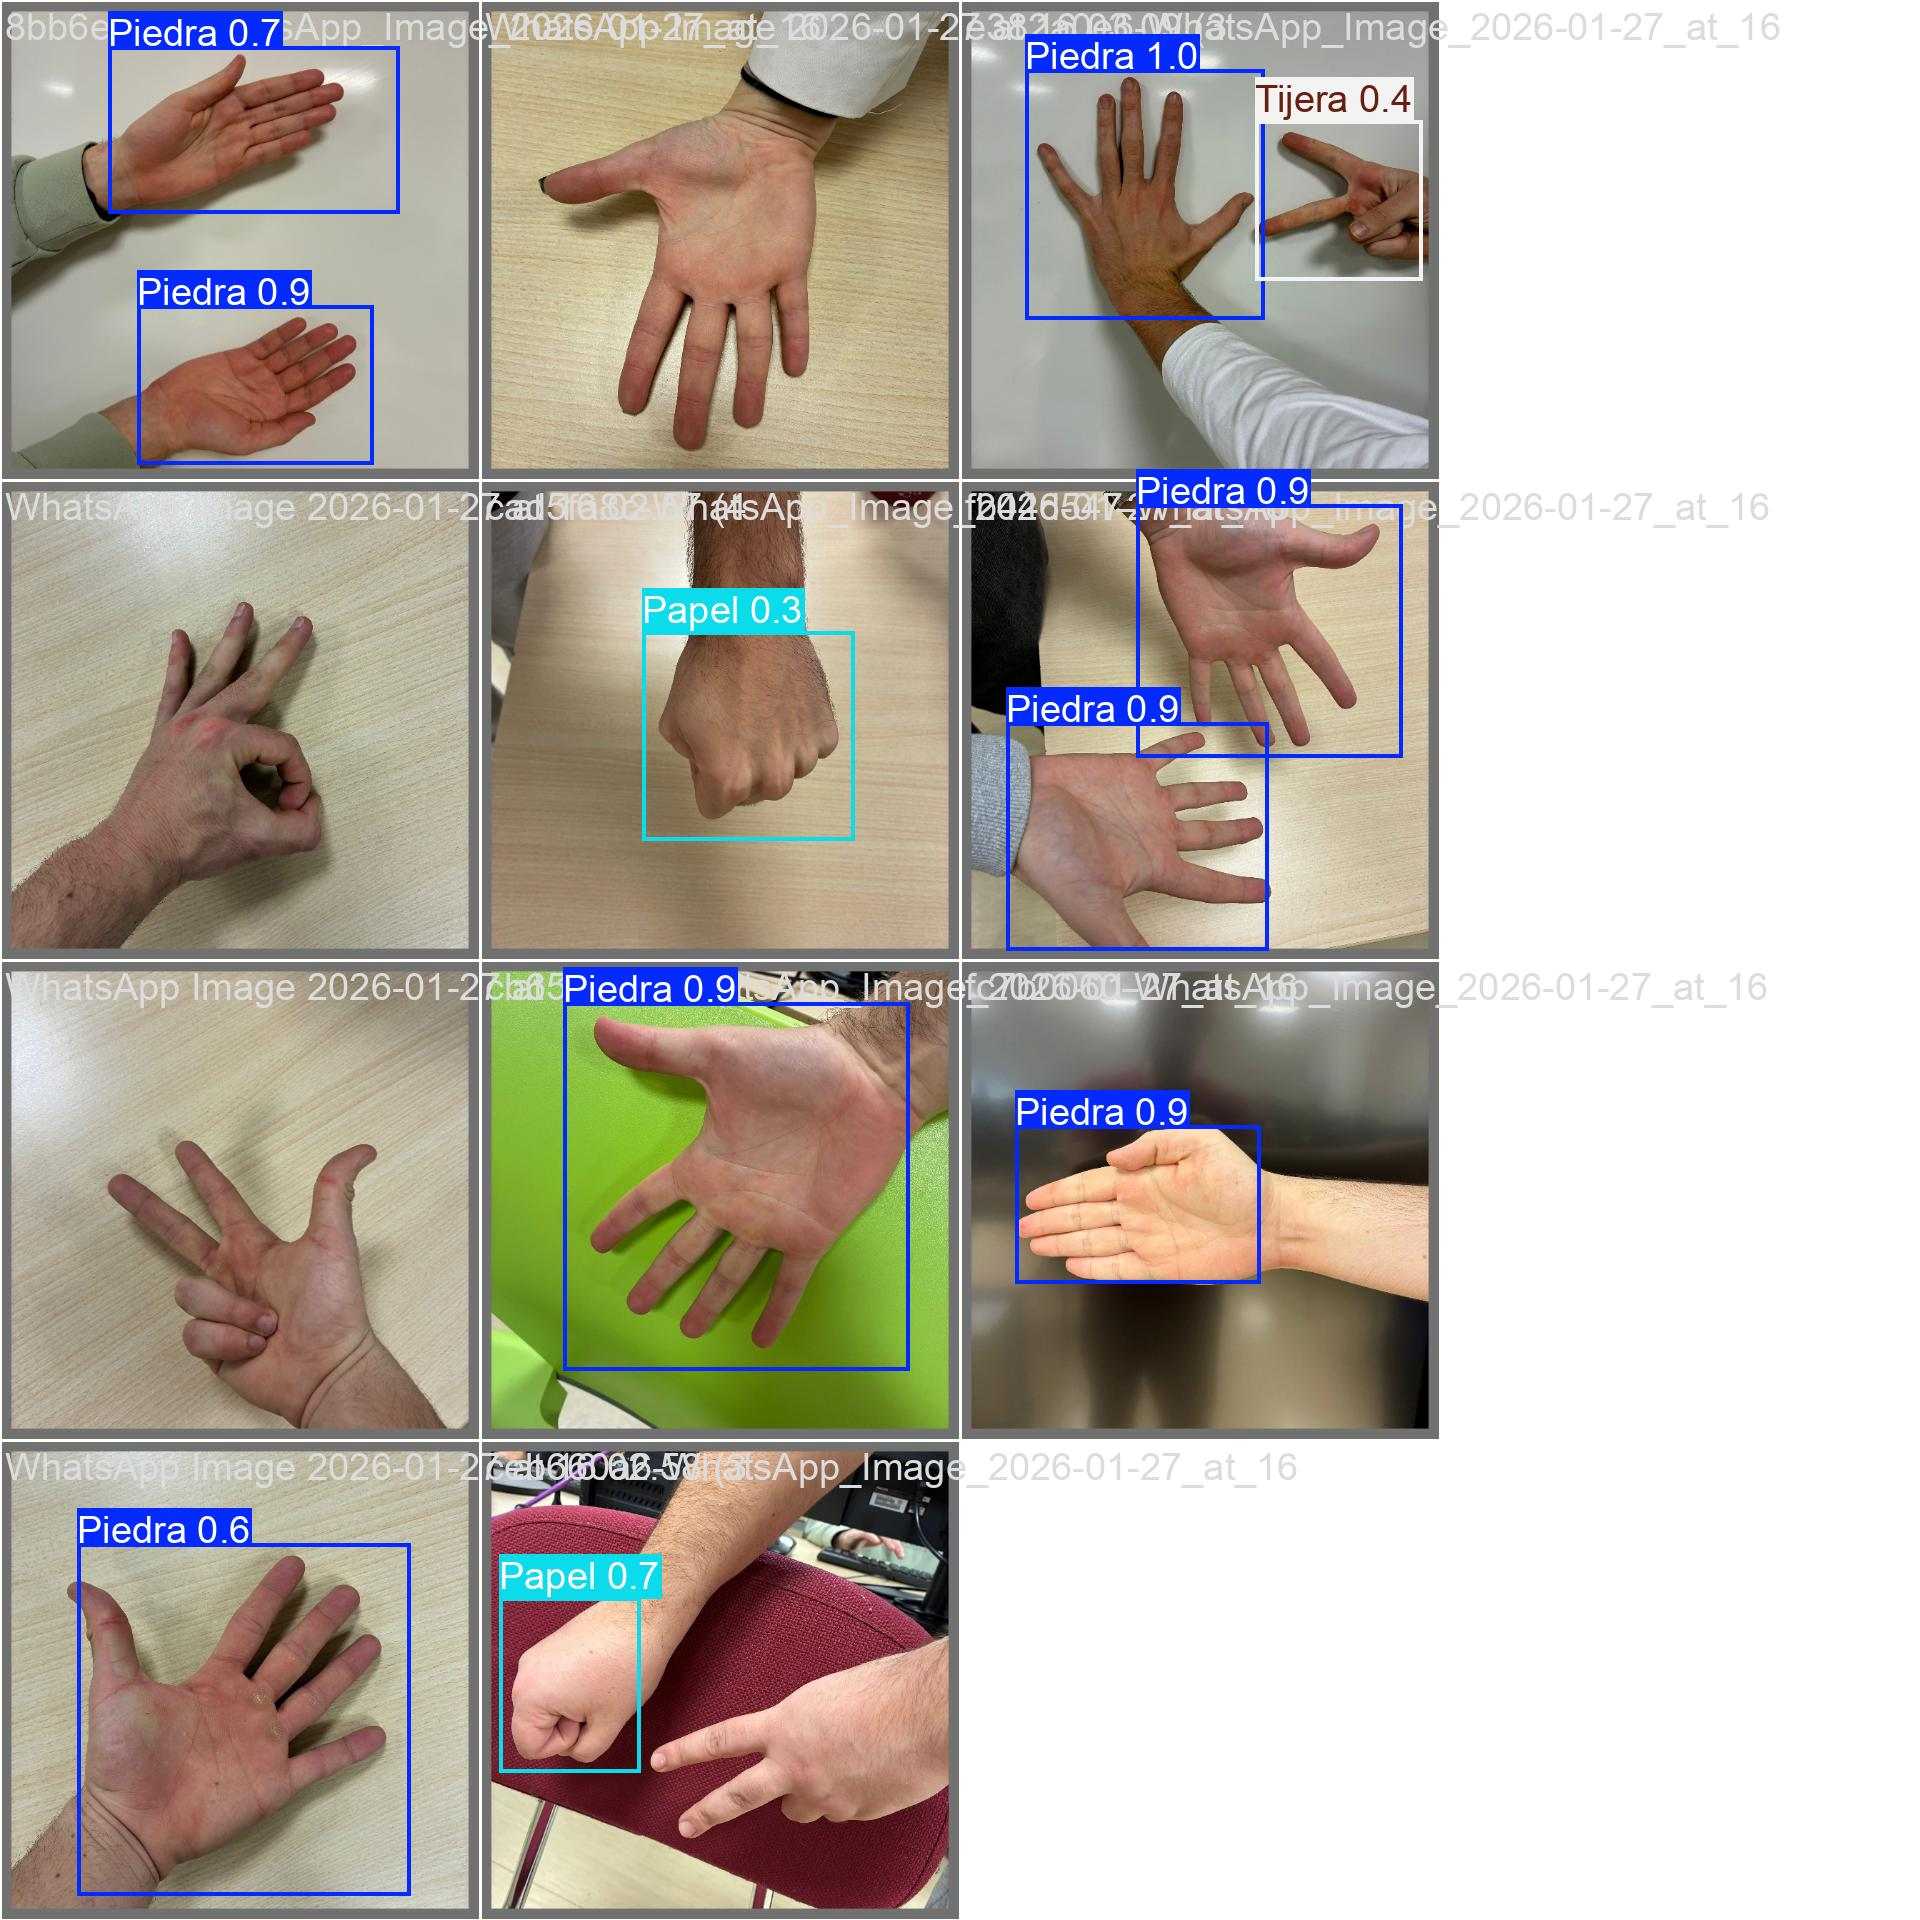


Ground Truth:


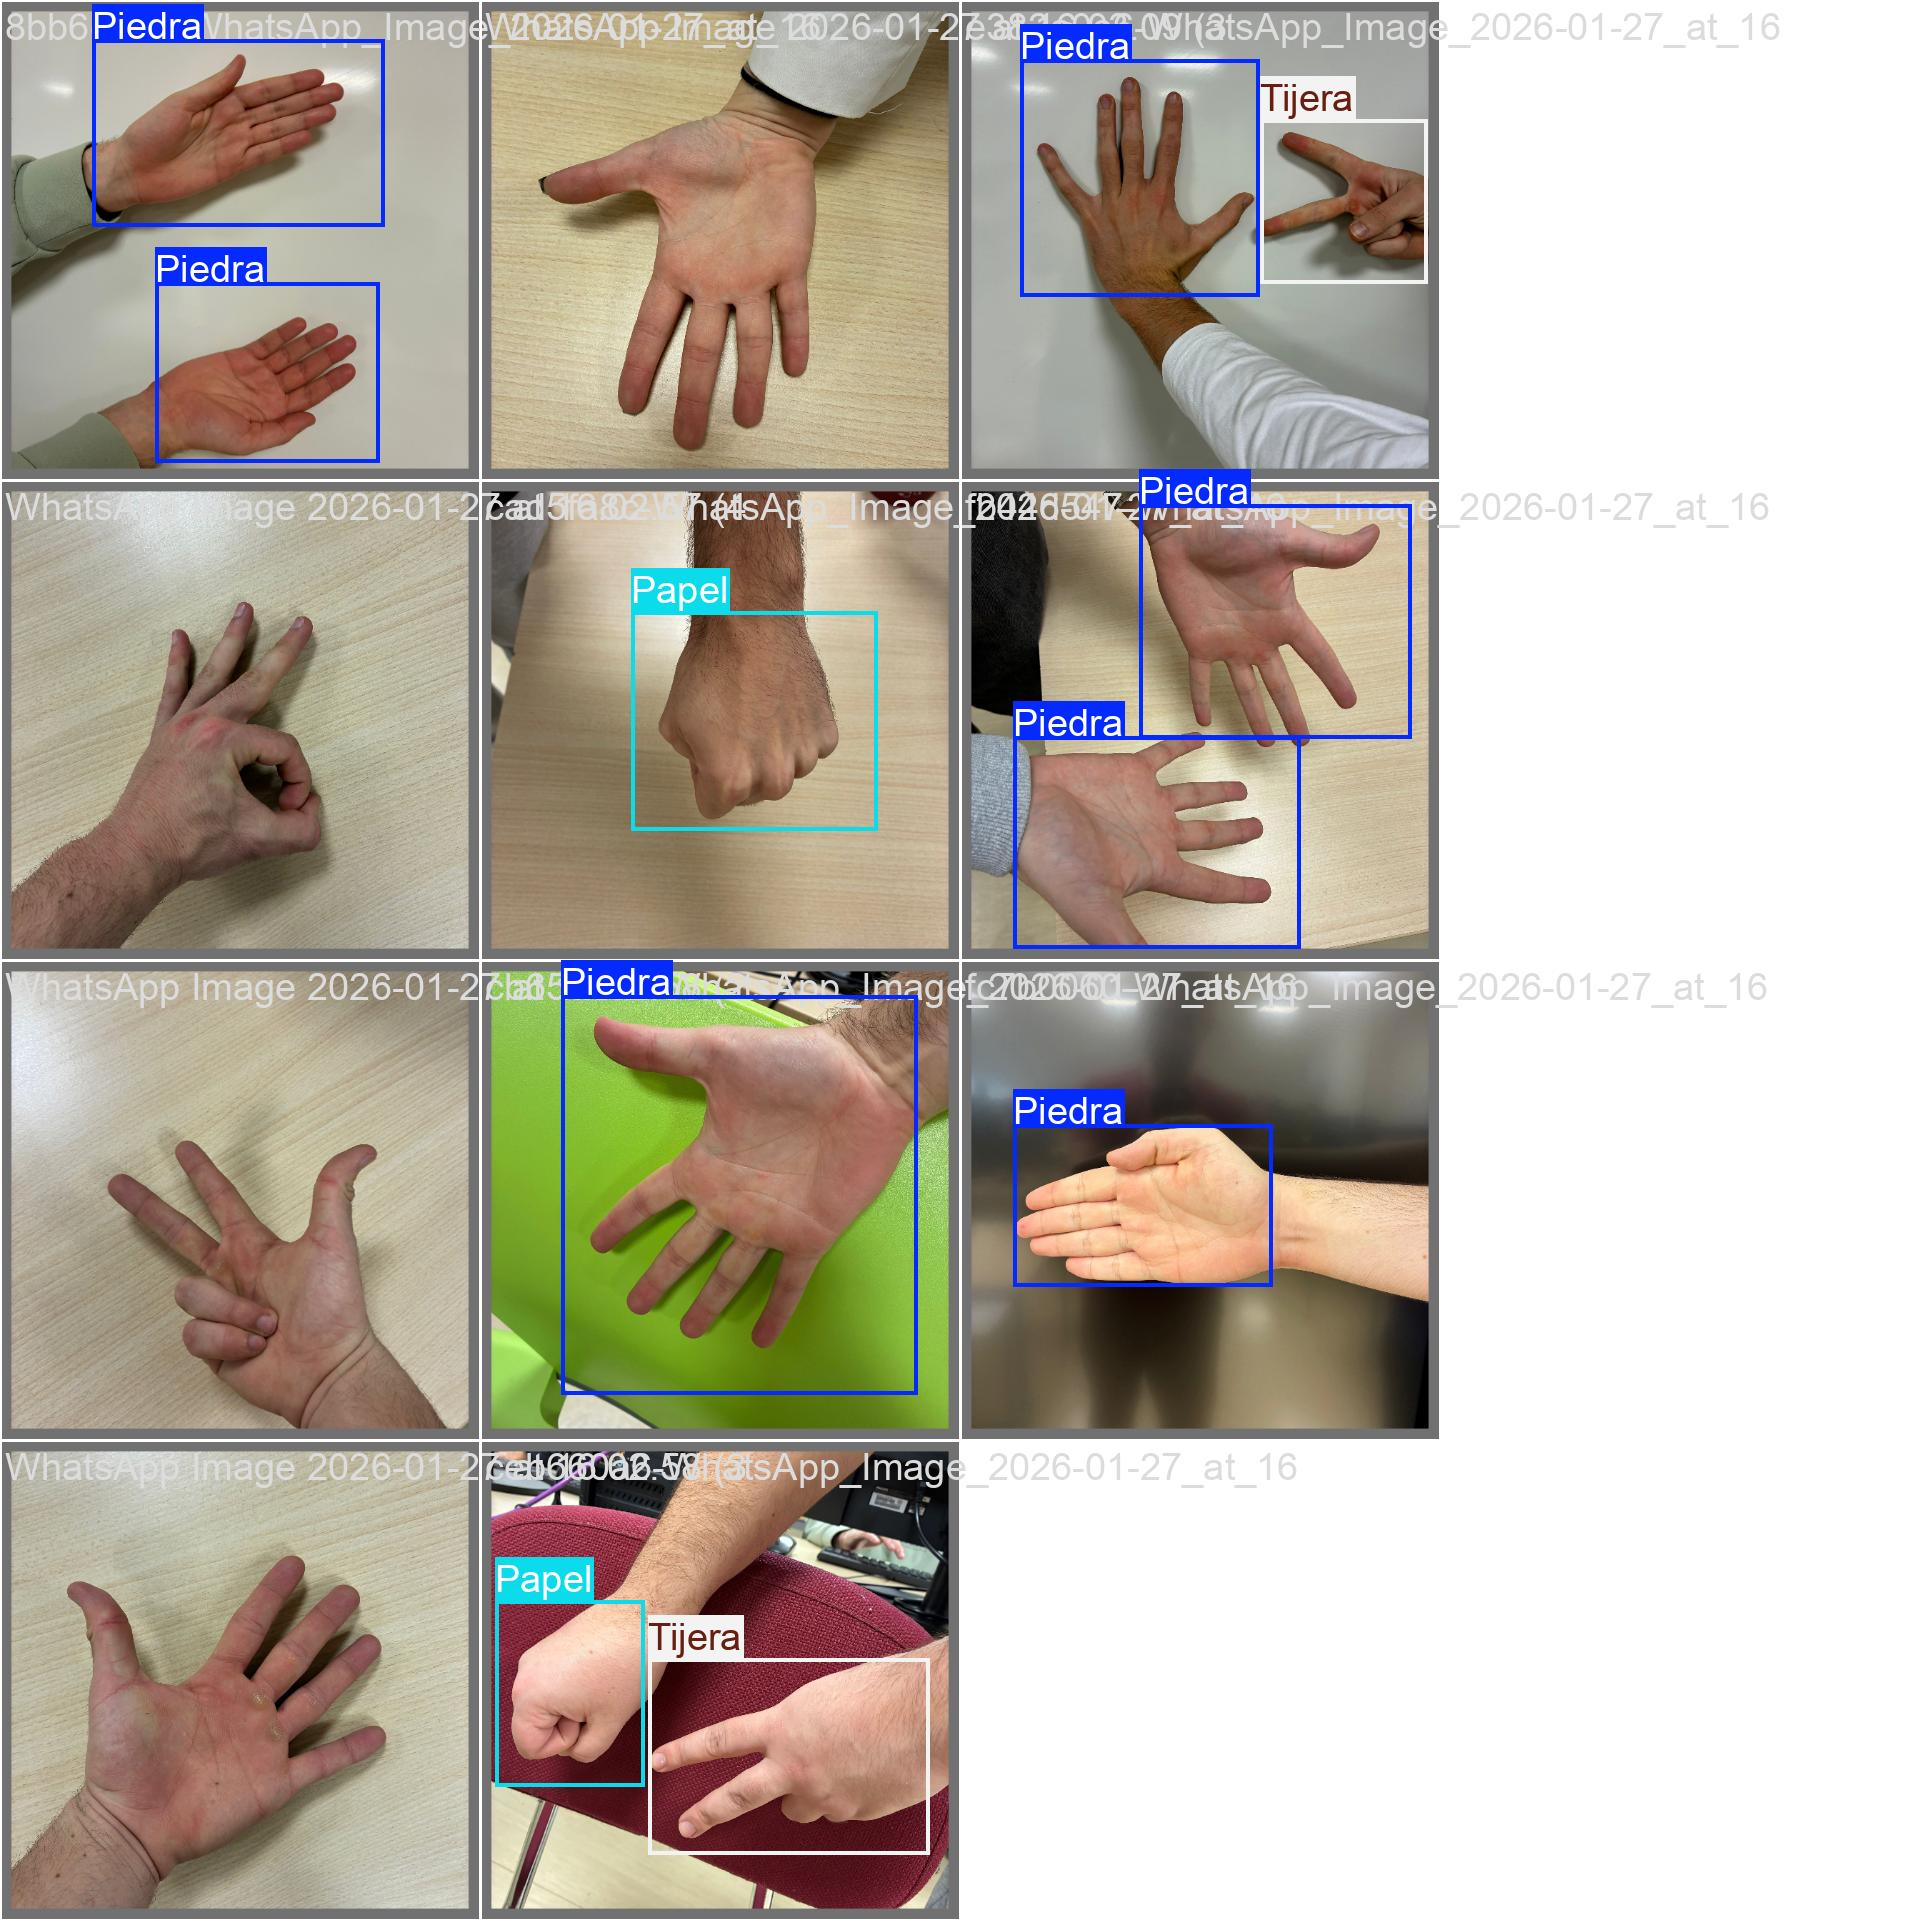


Matriz de confusión:


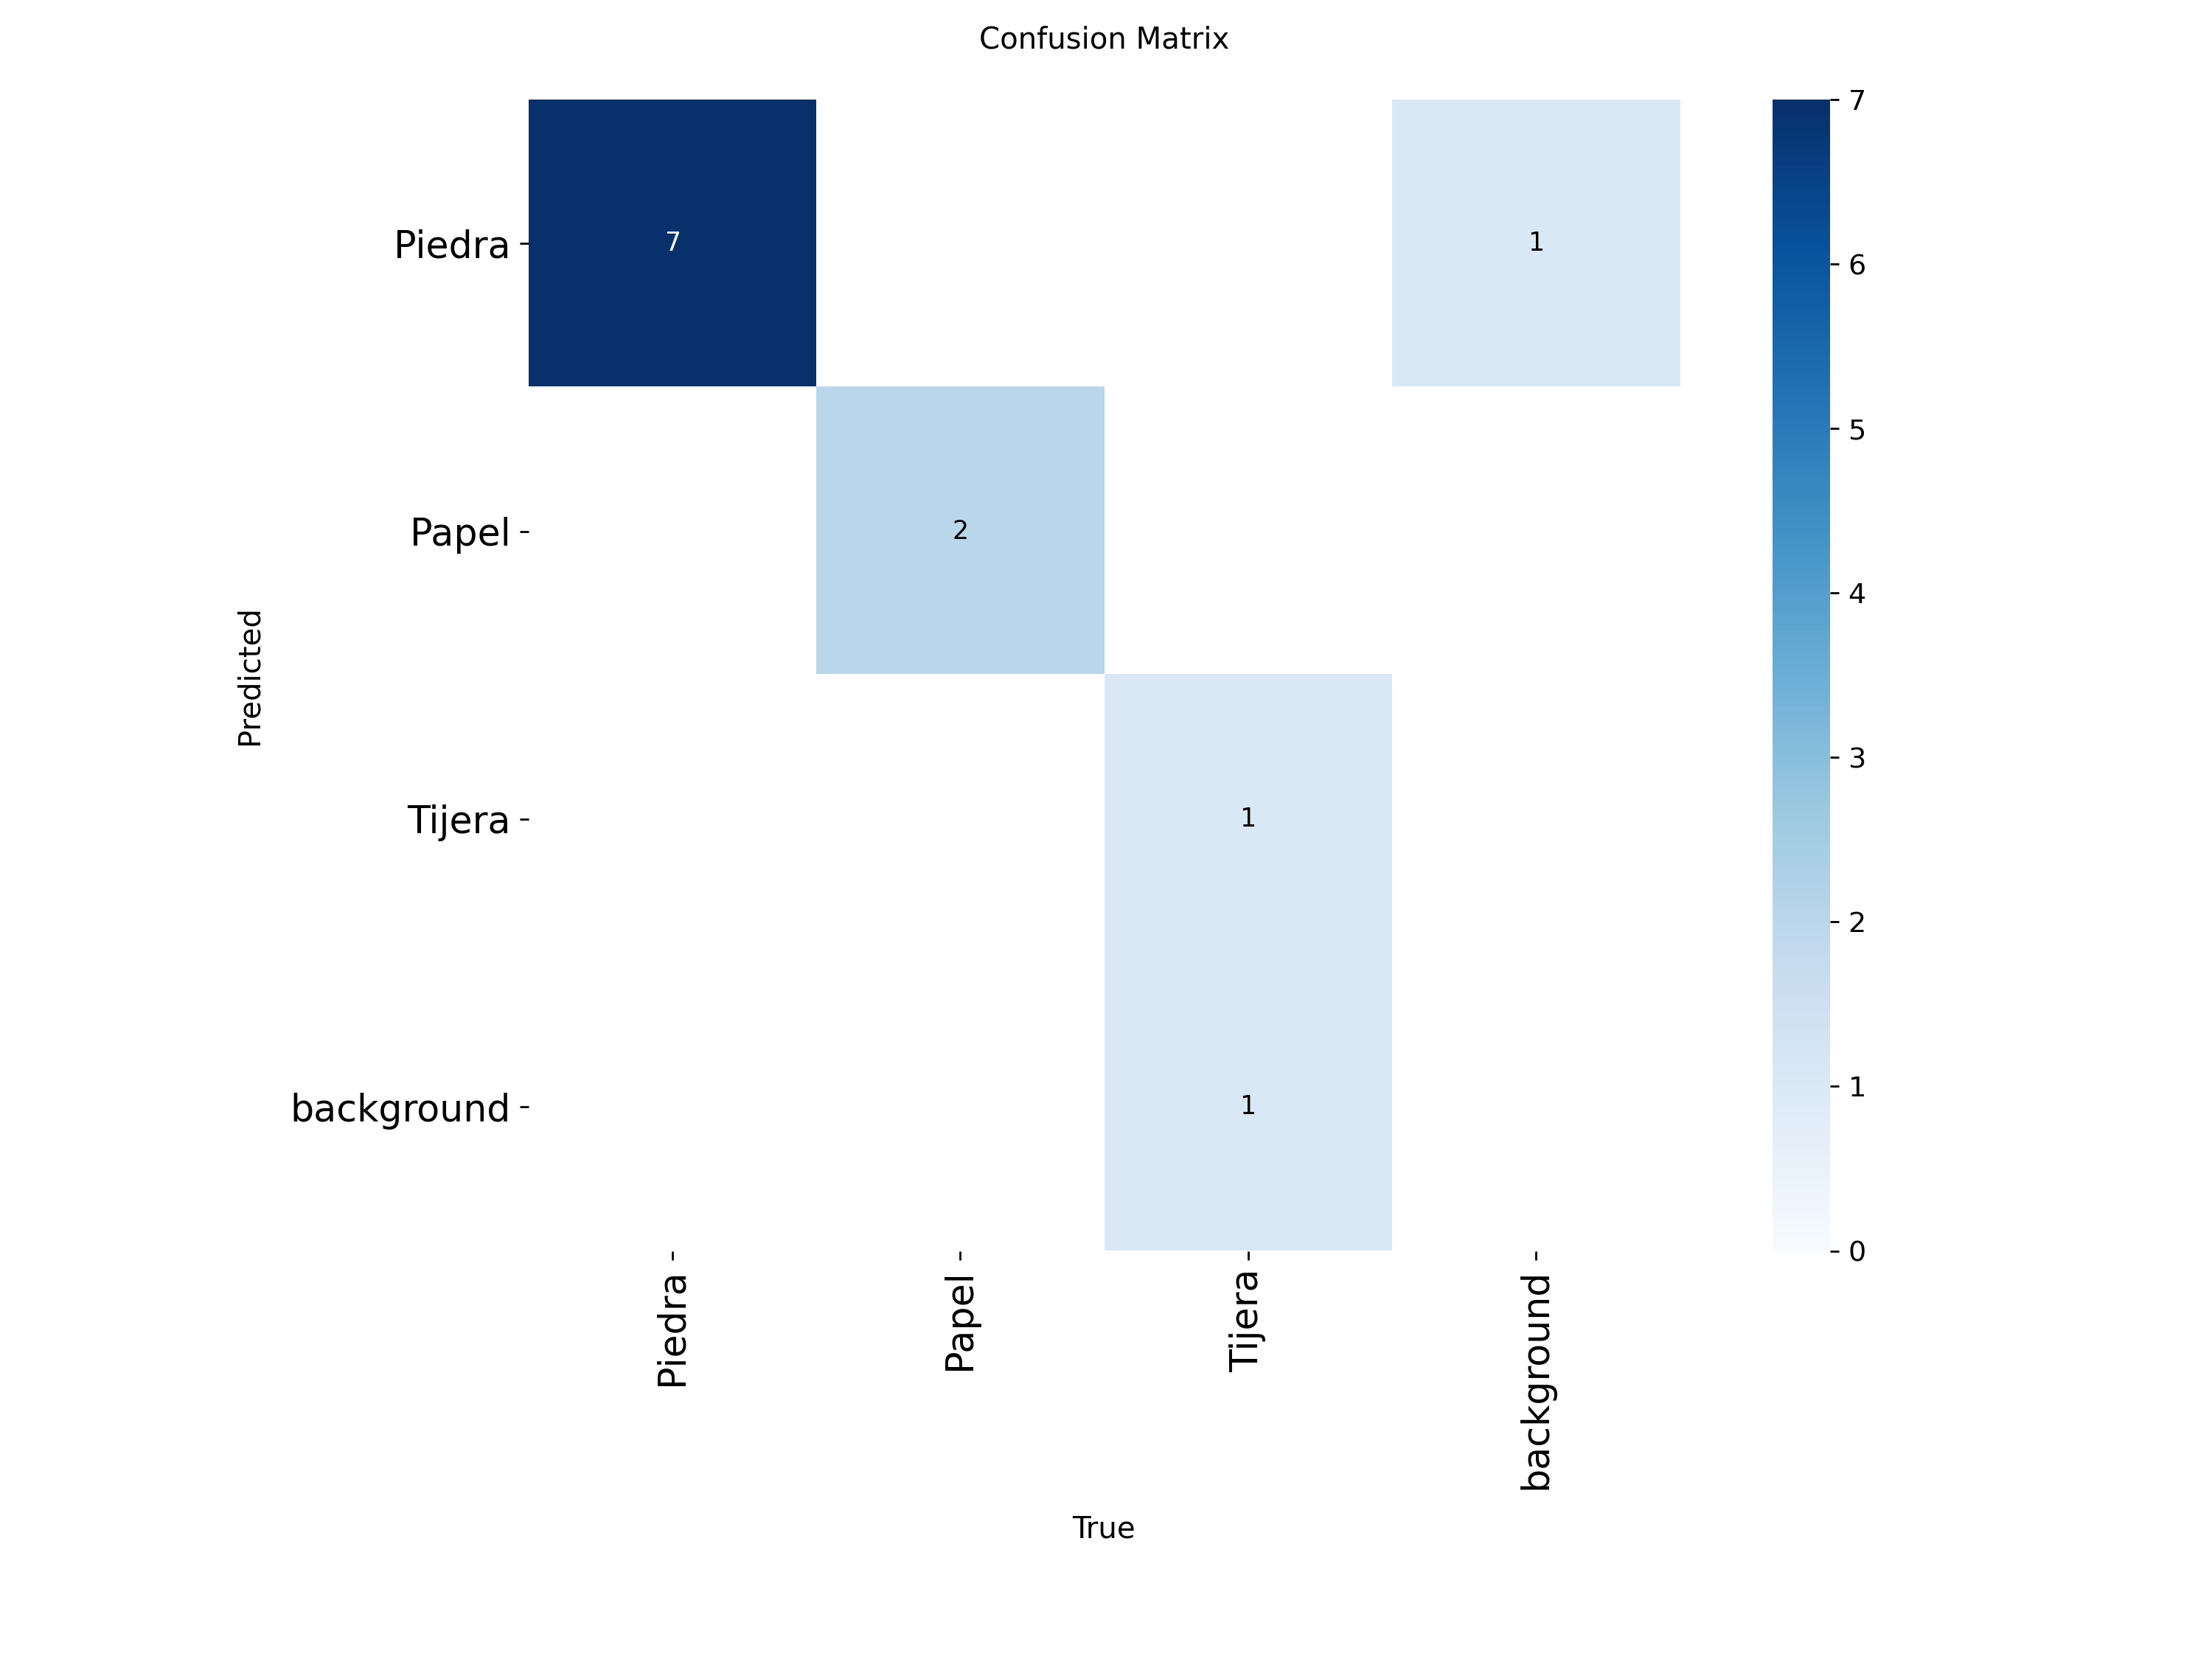

Metricas

Época final: 50
mAP50 (Detección): 0.9950
mAP50-95 (Detección): 0.6846


KeyError: 'metrics/mAP50(M)'

In [7]:
import os
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

# Ruta a resultados
results_path = f'runs/detect/train'

print(f"Resultados en: {results_path}\n")

# Mostrar imágenes principales
print("Visualizaciones")

imgs = {
    'Curvas de entrenamiento': 'results.png',
    'Predicciones de validación': 'val_batch0_pred.jpg',
    'Ground Truth': 'val_batch0_labels.jpg',
    'Matriz de confusión': 'confusion_matrix.png'
}

for titulo, archivo in imgs.items():
    path = f'{results_path}/{archivo}'
    if os.path.exists(path):
        print(f"\n{titulo}:")
        display(Image(filename=path, width=800))

# Métricas finales
print("Metricas")

df = pd.read_csv(f'{results_path}/results.csv')
ultima_epoca = df.iloc[-1]

print(f"\nÉpoca final: {int(ultima_epoca['epoch'])}")
print(f"mAP50 (Detección): {ultima_epoca['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95 (Detección): {ultima_epoca['metrics/mAP50-95(B)']:.4f}")
print(f"mAP50 (Segmentación): {ultima_epoca['metrics/mAP50(M)']:.4f}")
print(f"mAP50-95 (Segmentación): {ultima_epoca['metrics/mAP50-95(M)']:.4f}")

print("\nEntrenamiento completado")
print(f"Mejor modelo guardado en: {results_path}/weights/best.pt")